In [1]:
!pip install wfdb imblearn torchinfo 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 101.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
import numpy as np
import os 
import math
import warnings
import json
import random
import pandas as pd
import ast
import pywt
from tqdm.auto import tqdm 
import seaborn as sns

import wfdb
from wfdb.processing import xqrs_detect

import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

from scipy.signal import resample
from scipy.signal import butter, filtfilt
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchinfo import summary
import time, numpy as np, torch
from torch.ao.quantization import (
    QuantStub, DeQuantStub, get_default_qat_qconfig,
    prepare_qat, convert
)
import torch.quantization as tq
import torch.nn.quantized as nnq

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
mitdb_dir = "/kaggle/input/mitdb-incart-raw/MIT_BIH_Arrhythmia/"
incart_dir = "/kaggle/input/mitdb-incart-raw/INCART"
output_dir = "/kaggle/working/Outputs/"

CLASSES = ["N", "L", "R", "V", "A"]
LABEL_MAP = {s : i for i,s in enumerate (CLASSES)}
print("Joint class: ", CLASSES)

Joint class:  ['N', 'L', 'R', 'V', 'A']


## RAW: CANONICAL LABEL MAP

In [4]:
DICT_MITDB = {
    "N":"N","/":"N","f":"N","j":"N","|":"N","+":"N",
    "L":"L",
    "R":"R",
    "V":"V","E":"V","!":"V","e":"V",
    "F":"R",
    "A":"A","a":"A","J":"A","S":"A","n":"A"
}

In [5]:
DICT_INCART = {
    "N":"N",
    "V":"V","e":"V",
    "F":"R",
    "A":"A","n":"A","j":"A","S":"A",
    "R":"R"
}

In [6]:
# Label Encoder
def EncodeLabel(sym, dataset):
    if dataset == "MITDB":
        if sym not in DICT_MITDB:
            return None
        return LABEL_MAP[DICT_MITDB[sym]]

    elif dataset == "INCART":
        if sym not in DICT_INCART:
            return None
        return LABEL_MAP[DICT_INCART[sym]]


# IIR Bandpass Filter 
def BandpassFilter_IIR(sig, fs=360, lowcut=0.5, highcut=40, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, sig).astype(np.float32)


# Wavelet Denoise
def WaveletDenoise(sig, wavelet="db6", level=4):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    thresh = sigma * np.sqrt(2 * np.log(len(sig)))

    coeffs_f = [coeffs[0]]
    for c in coeffs[1:]:
        coeffs_f.append(pywt.threshold(c, thresh, mode="soft"))

    return pywt.waverec(coeffs_f, wavelet).astype(np.float32)



# Extract 320 Sample for 1 Beat
def ExtractBeat(sig, r_peak, before=159, after=160):
    s = r_peak - before
    e = r_peak + after + 1
    if s < 0 or e > len(sig):
        return None

    b = sig[s:e]
    b = (b - b.mean()) / (b.std() + 1e-8)
    return b.astype(np.float32)

In [7]:
# Select MLII Channel for MIT-BIH Dataset
def SelectMLIIChannel_MITDB(sig, sig_names):
    names = [s.upper() for s in (sig_names or [])]
    if "MLII" not in names:
        return None
    return sig[:, names.index("MLII")].astype(np.float32)



def LabelRpeak_INCART(rp, ann_pos, ann_sym, max_dist=80):
    """
    Assign label to detected R-peak using nearest annotation.
    Reject if too far from any annotation.
    """
    idx = np.searchsorted(ann_pos, rp)

    if idx == 0:
        near, sym = ann_pos[0], ann_sym[0]
    elif idx == len(ann_pos):
        near, sym = ann_pos[-1], ann_sym[-1]
    else:
        left, right = ann_pos[idx-1], ann_pos[idx]
        if abs(rp - left) < abs(rp - right):
            near, sym = left, ann_sym[idx-1]
        else:
            near, sym = right, ann_sym[idx]

    if abs(rp - near) > max_dist:
        return None

    return LABEL_MAP[sym]


# Select Lead II --> Lead I --> V1 Channel for MIT-BIH Dataset
def SelectChannel_INCART(sig, sig_names):
    if sig_names is None:
        return sig[:, 0].astype(np.float32)

    names = [s.upper() for s in sig_names]
    for p in ["II", "I", "V1"]:
        if p in names:
            return sig[:, names.index(p)].astype(np.float32)
    return sig[:, 0].astype(np.float32)
    

# Resample to 360Hz for INCART 
def ResampleTo360Hz(sig, fs_old, fs_new=360):
    if fs_old == fs_new:
        return sig.astype(np.float32)
    N_new = int(len(sig) * fs_new / fs_old)
    return resample(sig, N_new).astype(np.float32)




def ProcessRecord_MITDB(rc_path):
    sig, fields = wfdb.rdsamp(rc_path)
    ann = wfdb.rdann(rc_path, "atr")

    sig_1d = SelectMLIIChannel_MITDB(sig, fields.get("sig_name"))
    if sig_1d is None:
        return np.empty((0,320), np.float32), []

    sig_1d = BandpassFilter_IIR(sig_1d, fs=360)

    beats = []
    labels = []

    for rp, sym in zip(ann.sample, ann.symbol):
        y = EncodeLabel(sym, "MITDB")
        if y is None:
            continue

        beat = ExtractBeat(sig_1d, rp)
        if beat is None:
            continue

        beats.append(beat)
        labels.append(y)

    if not beats:
        return np.empty((0,320), np.float32), []

    return np.stack(beats), labels



def ProcessRecord_INCART(rc_path):
    sig, fields = wfdb.rdsamp(rc_path)
    ann = wfdb.rdann(rc_path, "atr")

    # --- signal ---
    sig_1d = SelectChannel_INCART(sig, fields.get("sig_name"))
    sig_1d = ResampleTo360Hz(sig_1d, fields["fs"])
    sig_1d = BandpassFilter_IIR(sig_1d, fs=360)
    sig_1d = WaveletDenoise(sig_1d)

    # --- annotations ---
    syms = np.asarray(ann.symbol)
    samp = np.asarray(ann.sample)

    valid = [i for i, s in enumerate(syms) if s in DICT_INCART]
    ann_pos = (samp[valid] * 360 / fields["fs"]).astype(int)
    ann_sym = [DICT_INCART[syms[i]] for i in valid]

    # --- detect R-peaks ---
    r_peaks = xqrs_detect(sig=sig_1d, fs=360)

    beats = []
    labels = []

    for rp in r_peaks:
        lab = LabelRpeak_INCART(rp, ann_pos, ann_sym)
        if lab is None:
            continue

        beat = ExtractBeat(sig_1d, rp)
        if beat is None:
            continue

        beats.append(beat)
        labels.append(lab)

    if not beats:
        return np.empty((0,320), np.float32), []

    return np.stack(beats), labels




def WriteSignalnLabel(sig_2d, labels, signal_path, label_path):
    assert sig_2d.shape[0] == len(labels)
    with open(signal_path, "w") as fs, open(label_path, "w") as fl:
        for b, y in zip(sig_2d, labels):
            fs.write(" ".join(f"{x:.6f}" for x in b) + "\n")
            fl.write(f"{int(y)}\n")


def BuildJointDataset(mit_records, incart_records):
    all_beats, all_labels, all_sources = [], [], []

    for rc in mit_records:
        b, y = ProcessRecord_MITDB(os.path.join(mitdb_dir, str(rc)))
        all_beats.append(b)
        all_labels.extend(y)
        all_sources.extend(["MITDB"] * len(y))

    for rc in incart_records:
        b, y = ProcessRecord_INCART(os.path.join(incart_dir, rc))
        all_beats.append(b)
        all_labels.extend(y)
        all_sources.extend(["INCART"] * len(y))

    X = np.concatenate(all_beats, axis=0)
    y = np.array(all_labels)

    return X, y, np.array(all_sources)


In [8]:
# Call all record of MIT-BIH
mit_records = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

# Call all record of INCART
incart_records = [f"I{str(i).zfill(2)}" for i in range(1,76)]


# Build Data
X, y, src = BuildJointDataset(mit_records, incart_records)

print("Total beats:", len(y))
print("Class distribution:", np.bincount(y))


Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learn

In [9]:
def show_beat_record(
    dataset,
    rc_path,
    before=159,
    after=160,
    qrs_half_width=20,
    zoom_window=60
):
    """
    Show ONE random beat directly from a record (before concatenation).
    """

    assert dataset in ["MITDB", "INCART"]

    # =====================
    # LOAD RECORD
    # =====================
    sig, fields = wfdb.rdsamp(rc_path)
    ann = wfdb.rdann(rc_path, "atr")

    if dataset == "MITDB":
        sig_1d = SelectMLIIChannel_MITDB(sig, fields.get("sig_name"))
        if sig_1d is None:
            print("No MLII channel")
            return

        sig_1d = BandpassFilter_IIR(sig_1d, fs=360)

        # random annotated beat
        idx = np.random.randint(len(ann.sample))
        rp = ann.sample[idx]
        y = EncodeLabel(ann.symbol[idx], "MITDB")

    else:  # INCART
        sig_1d = SelectChannel_INCART(sig, fields.get("sig_name"))
        sig_1d = ResampleTo360Hz(sig_1d, fields["fs"])
        sig_1d = BandpassFilter_IIR(sig_1d, fs=360)
        sig_1d = WaveletDenoise(sig_1d)

        syms = np.asarray(ann.symbol)
        samp = np.asarray(ann.sample)

        valid = [i for i, s in enumerate(syms) if s in DICT_INCART]
        ann_pos = (samp[valid] * 360 / fields["fs"]).astype(int)
        ann_sym = [DICT_INCART[syms[i]] for i in valid]

        r_peaks = xqrs_detect(sig=sig_1d, fs=360)
        rp = np.random.choice(r_peaks)
        y = LabelRpeak_INCART(rp, ann_pos, ann_sym)

    if y is None:
        print("Invalid beat label")
        return

    beat = ExtractBeat(sig_1d, rp, before, after)
    if beat is None:
        print("Beat out of bounds")
        return

    label_name = CLASSES[y]

    # =====================
    # PRINT INFO
    # =====================
    print("="*45)
    print(f"Dataset         : {dataset}")
    print(f"Record          : {os.path.basename(rc_path)}")
    print(f"R-peak index    : {rp}")
    print(f"Class           : {label_name} ({y})")
    print(f"Min / Max       : {beat.min():.3f} / {beat.max():.3f}")
    print(f"Mean / Std      : {beat.mean():.3f} / {beat.std():.3f}")
    print("="*45)

    # =====================
    # PLOT
    # =====================
    x = np.arange(len(beat))
    r_loc = before

    plt.figure(figsize=(12,4))
    plt.plot(x, beat, lw=1.5, label="ECG Beat")

    plt.axvspan(
        r_loc - qrs_half_width,
        r_loc + qrs_half_width,
        color="yellow", alpha=0.25, label="QRS"
    )
    plt.axvline(r_loc, color="red", linestyle="--", label="R-peak")

    plt.title(f"[{dataset}] Beat | Class {label_name}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude (Z-score)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Zoom
    z1 = max(0, r_loc - zoom_window)
    z2 = min(len(beat), r_loc + zoom_window)

    plt.figure(figsize=(12,3))
    plt.plot(x[z1:z2], beat[z1:z2], lw=1.5)
    plt.axvline(r_loc, color="red", linestyle="--")
    plt.axvspan(
        r_loc - qrs_half_width,
        r_loc + qrs_half_width,
        color="yellow", alpha=0.25
    )
    plt.title(f"Zoomed View (±{zoom_window})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




def show_beat(
    X, y,
    idx=None,
    class_names=None,
    r_loc=159,
    qrs_half_width=20,
    zoom_window=60
):
    """
    Visualize an ECG beat to sanity-check beat extraction.

    Parameters
    ----------
    X : np.ndarray, shape (N, 320)
        Beat signals
    y : np.ndarray, shape (N,)
        Labels
    idx : int or None
        Beat index (random if None)
    class_names : list or None
        Class name list, e.g. ["N","L","R","V","A"]
    r_loc : int
        R-peak index inside beat
    qrs_half_width : int
        Half width of QRS region (samples)
    zoom_window : int
        Half width of zoom window (samples)
    """

    assert X.ndim == 2, "X must be 2D (N, 320)"
    assert X.shape[1] == 320, "Each beat must have length 320"

    if idx is None:
        idx = np.random.randint(0, len(X))

    beat = X[idx]
    label = int(y[idx])

    if class_names is None:
        label_name = str(label)
    else:
        label_name = class_names[label]

    # -----------------------
    # Basic stats
    # -----------------------
    beat_min  = beat.min()
    beat_max  = beat.max()
    beat_mean = beat.mean()
    beat_std  = beat.std()

    print("="*40)
    print(f"Beat index      : {idx}")
    print(f"Class           : {label_name} ({label})")
    print(f"Min / Max       : {beat_min:.3f} / {beat_max:.3f}")
    print(f"Mean / Std      : {beat_mean:.3f} / {beat_std:.3f}")
    print("="*40)

    x = np.arange(len(beat))

    # =======================
    # FIGURE 1: Full beat
    # =======================
    plt.figure(figsize=(12,4))
    plt.plot(x, beat, lw=1.5, label="ECG Signal")

    qrs_start = r_loc - qrs_half_width
    qrs_end   = r_loc + qrs_half_width

    plt.axvspan(qrs_start, qrs_end,
                color="yellow", alpha=0.25, label="QRS zone")

    plt.axvline(r_loc, color="red", linestyle="--", lw=1.2, label="R-peak")

    plt.title(
        f"ECG Beat #{idx} | Class {label_name}\n"
        f"min={beat_min:.2f}, max={beat_max:.2f}, mean={beat_mean:.2f}",
        fontsize=13
    )
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude (Z-score)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =======================
    # FIGURE 2: Zoomed view
    # =======================
    z1 = max(0, r_loc - zoom_window)
    z2 = min(len(beat), r_loc + zoom_window)

    plt.figure(figsize=(12,3))
    plt.plot(x[z1:z2], beat[z1:z2], lw=1.5, label="Zoomed ECG")

    plt.axvline(r_loc, color="red", linestyle="--", lw=1.2, label="R-peak")
    plt.axvspan(qrs_start, qrs_end, color="yellow", alpha=0.25)

    plt.title(f"Zoomed View Around R-peak (±{zoom_window} samples)", fontsize=12)
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Dataset         : MITDB
Record          : 107
R-peak index    : 576081
Class           : N (0)
Min / Max       : -2.965 / 2.763
Mean / Std      : 0.000 / 1.000


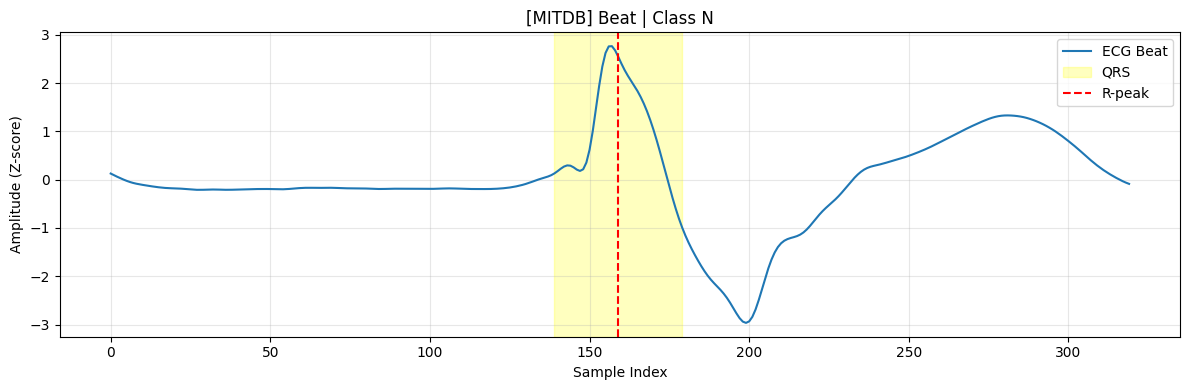

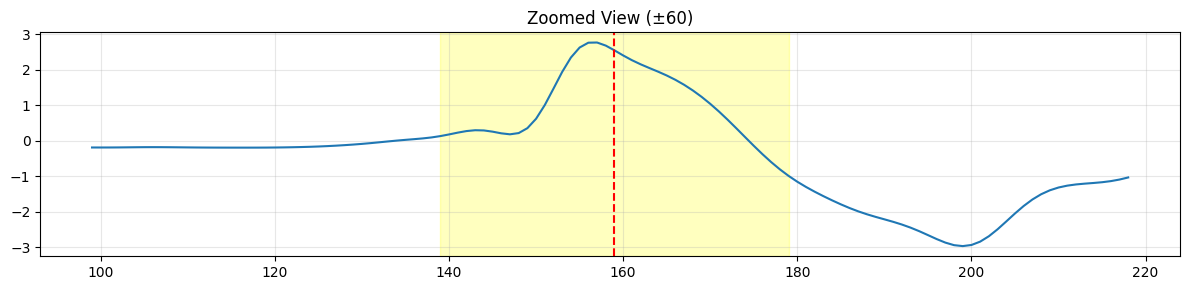

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Dataset         : INCART
Record          : I02
R-peak index    : 516864
Class           : N (0)
Min / Max       : -1.960 / 4.640
Mean / Std      : -0.000 / 1.000


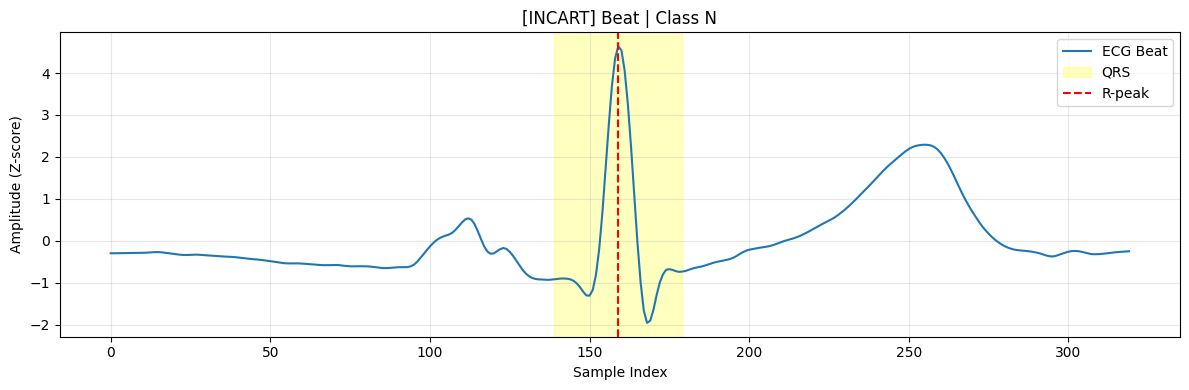

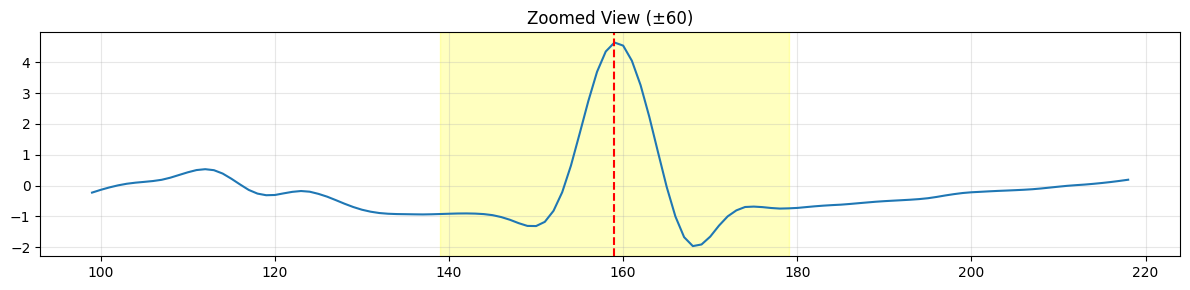

In [10]:
# MIT-BIH
show_beat_record(
    dataset="MITDB",
    rc_path=os.path.join(mitdb_dir, "107")
)

# INCART
show_beat_record(
    dataset="INCART",
    rc_path=os.path.join(incart_dir, "I02")
)

In [11]:
def compare_waveform(
    X_mit, y_mit,
    X_inc, y_inc,
    class_id,
    class_names,
    mode="mean",              # "single" | "mean"
    r_peak_idx=159,
    qrs_half_width=30,
    max_samples=500,
    return_metric=True
):
    """
    Compare ECG waveform between MIT-BIH and INCART for ONE class.

    Parameters
    ----------
    X_mit, y_mit : MIT-BIH beats and labels
    X_inc, y_inc : INCART beats and labels
    class_id     : int (index in class_names)
    class_names  : list of str
    mode         : "single" or "mean"
    r_peak_idx   : R-peak location in beat
    qrs_half_width : QRS half width (samples)
    max_samples  : max beats per dataset (for mean/std)
    return_metric: return similarity metrics or not
    """

    cls_name = class_names[class_id]

    idx_mit = np.where(y_mit == class_id)[0]
    idx_inc = np.where(y_inc == class_id)[0]

    if len(idx_mit) == 0 or len(idx_inc) == 0:
        print(f"[SKIP] Class {cls_name} not available in both datasets")
        return None

    # -------------------------
    # MODE: SINGLE BEAT
    # -------------------------
    if mode == "single":
        i_mit = np.random.choice(idx_mit)
        i_inc = np.random.choice(idx_inc)

        beat_mit = X_mit[i_mit]
        beat_inc = X_inc[i_inc]

        x = np.arange(len(beat_mit))

        plt.figure(figsize=(10,4))
        plt.plot(x, beat_mit, lw=2, label="MIT-BIH")
        plt.plot(x, beat_inc, lw=2, alpha=0.85, label="INCART")

        plt.axvline(r_peak_idx, color="r", ls="--")
        plt.axvspan(
            r_peak_idx - qrs_half_width,
            r_peak_idx + qrs_half_width,
            color="yellow", alpha=0.2
        )

        plt.title(f"Single Beat Comparison – Class {cls_name}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude (Z-score)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        return None

    # -------------------------
    # MODE: MEAN ± STD
    # -------------------------
    if mode == "mean":

        if len(idx_mit) > max_samples:
            idx_mit = np.random.choice(idx_mit, max_samples, replace=False)
        if len(idx_inc) > max_samples:
            idx_inc = np.random.choice(idx_inc, max_samples, replace=False)

        beats_mit = X_mit[idx_mit]
        beats_inc = X_inc[idx_inc]

        mean_mit = beats_mit.mean(axis=0)
        std_mit  = beats_mit.std(axis=0)

        mean_inc = beats_inc.mean(axis=0)
        std_inc  = beats_inc.std(axis=0)

        x = np.arange(len(mean_mit))

        plt.figure(figsize=(10,4))

        plt.plot(x, mean_mit, lw=2, label="MIT-BIH (mean)")
        plt.fill_between(
            x, mean_mit - std_mit, mean_mit + std_mit,
            alpha=0.2
        )

        plt.plot(x, mean_inc, lw=2, label="INCART (mean)")
        plt.fill_between(
            x, mean_inc - std_inc, mean_inc + std_inc,
            alpha=0.2
        )

        plt.axvline(r_peak_idx, color="r", ls="--")
        plt.axvspan(
            r_peak_idx - qrs_half_width,
            r_peak_idx + qrs_half_width,
            color="yellow", alpha=0.15
        )

        plt.title(f"Mean ± Std Waveform – Class {cls_name}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude (Z-score)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # -------------------------
        # METRICS (QRS ONLY)
        # -------------------------
        qrs = slice(
            r_peak_idx - qrs_half_width,
            r_peak_idx + qrs_half_width
        )

        cosine_sim = np.dot(
            mean_mit[qrs], mean_inc[qrs]
        ) / (
            np.linalg.norm(mean_mit[qrs]) *
            np.linalg.norm(mean_inc[qrs]) + 1e-8
        )

        l2_dist = np.linalg.norm(
            mean_mit[qrs] - mean_inc[qrs]
        )

        metrics = {
            "class": cls_name,
            "cosine_similarity_qrs": float(cosine_sim),
            "l2_distance_qrs": float(l2_dist),
            "n_mit": len(idx_mit),
            "n_inc": len(idx_inc)
        }

        if return_metric:
            return metrics

        return None

    raise ValueError("mode must be 'single' or 'mean'")

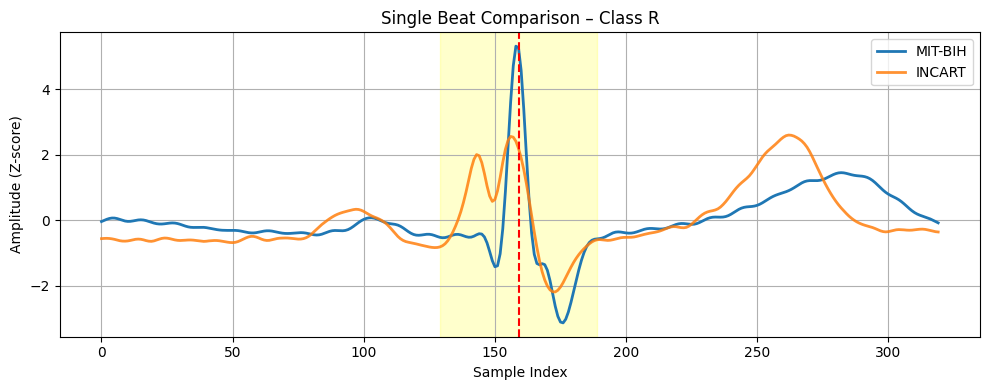

In [12]:
mask_mit = (src == "MITDB")
mask_inc = (src == "INCART")

X_mit = X[mask_mit]
y_mit = y[mask_mit]

X_inc = X[mask_inc]
y_inc = y[mask_inc]


compare_waveform(
    X_mit, y_mit,
    X_inc, y_inc,
    class_id=CLASSES.index("R"),
    class_names=CLASSES,
    mode="single"
)

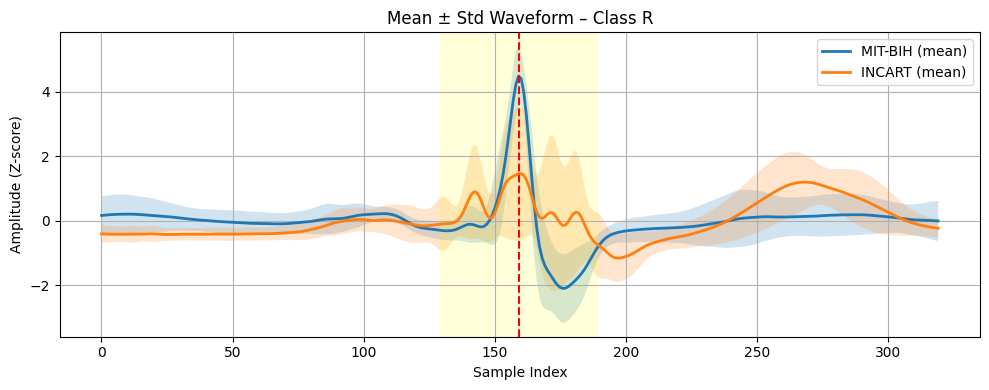

{'class': 'R', 'cosine_similarity_qrs': 0.6891393341949248, 'l2_distance_qrs': 10.974767684936523, 'n_mit': 500, 'n_inc': 500}


In [13]:
metrics = compare_waveform(
    X_mit, y_mit,
    X_inc, y_inc,
    class_id=CLASSES.index("R"),
    class_names=CLASSES,
    mode="mean"
)

print(metrics)

In [14]:
def downsample(
    X, y,
    target_per_class: dict,
    class_names=None,
    random_state=42,
    verbose=True
):
    """
    Downsample selected classes to target counts.

    Parameters
    ----------
    X : np.ndarray (N, ...)
    y : np.ndarray (N,)
    target_per_class : dict
        {class_id: target_count}
        e.g. {0: 30000}  # downsample class N
    class_names : list or None
        Optional class names for logging
    random_state : int
        For reproducibility
    """

    rng = np.random.default_rng(random_state)

    keep_indices = []

    unique_classes = np.unique(y)

    for c in unique_classes:
        idx = np.where(y == c)[0]
        n = len(idx)

        target = target_per_class.get(c, n)

        if target > n:
            raise ValueError(
                f"Target {target} > available {n} for class {c}"
            )

        if target < n:
            chosen = rng.choice(idx, target, replace=False)
            if verbose:
                name = class_names[c] if class_names else str(c)
                print(f"[Downsample] Class {name}: {n} → {target}")
        else:
            chosen = idx
            if verbose:
                name = class_names[c] if class_names else str(c)
                print(f"[Keep] Class {name}: {n}")

        keep_indices.append(chosen)

    keep_indices = np.concatenate(keep_indices)

    # Shuffle
    perm = rng.permutation(len(keep_indices))
    keep_indices = keep_indices[perm]

    X_new = X[keep_indices]
    y_new = y[keep_indices]

    if verbose:
        print("\n[Final distribution]")
        for c in unique_classes:
            name = class_names[c] if class_names else str(c)
            print(f"  {name}: {np.sum(y_new == c)}")

    return X_new, y_new



def plot_class_distribution(
    y_before,
    y_after,
    class_names,
    title="Class Distribution Before vs After Downsampling"
):
    """
    Plot class distribution before and after downsampling.

    Parameters
    ----------
    y_before : np.ndarray
        Labels before downsampling
    y_after : np.ndarray
        Labels after downsampling
    class_names : list of str
        Class names in order of label encoding
    """

    counts_before = [np.sum(y_before == i) for i in range(len(class_names))]
    counts_after  = [np.sum(y_after == i)  for i in range(len(class_names))]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(10,5))

    plt.bar(
        x - width/2,
        counts_before,
        width,
        label="Before",
        alpha=0.8
    )
    plt.bar(
        x + width/2,
        counts_after,
        width,
        label="After",
        alpha=0.8
    )

    plt.xticks(x, class_names)
    plt.ylabel("Number of Beats")
    plt.xlabel("Class")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print numbers (useful for log / paper)
    print("\nClass distribution:")
    for i, name in enumerate(class_names):
        print(
            f"  {name}: "
            f"{counts_before[i]} → {counts_after[i]}"
        )

In [15]:
X_bal, y_bal = downsample(
    X, y,
    target_per_class={
        CLASSES.index("N"): 30000
    },
    class_names=CLASSES
)

[Downsample] Class N: 228655 → 30000
[Keep] Class L: 8071
[Keep] Class R: 11414
[Keep] Class V: 27239
[Keep] Class A: 4838

[Final distribution]
  N: 30000
  L: 8071
  R: 11414
  V: 27239
  A: 4838


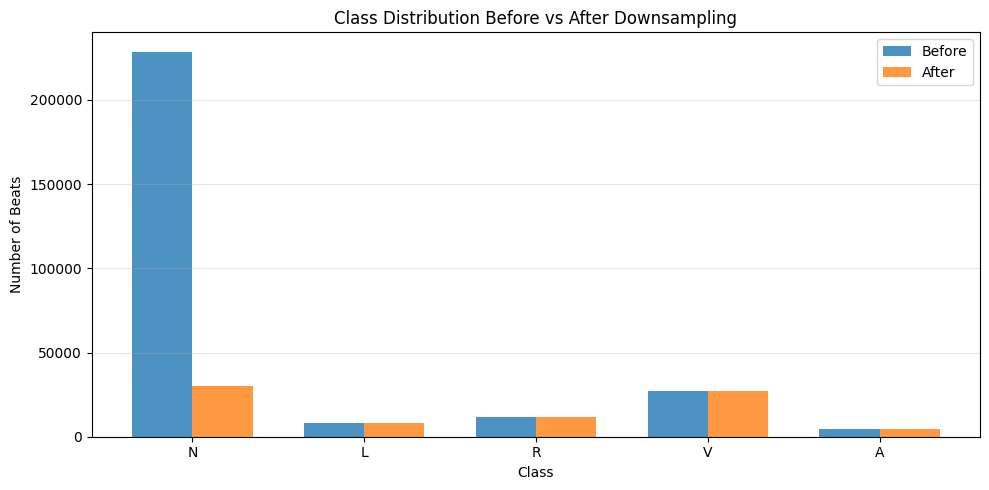


Class distribution:
  N: 228655 → 30000
  L: 8071 → 8071
  R: 11414 → 11414
  V: 27239 → 27239
  A: 4838 → 4838


In [16]:
plot_class_distribution(
    y_before=y,
    y_after=y_bal,
    class_names=CLASSES
)

# Prepare Dataset

In [17]:
def stratified_train_val_test_split(
    X, y,
    test_size=0.2,
    val_size=0.15,
    random_state=42
):
    """
    Split dataset into train / val / test with stratification.

    test_size: ratio of full dataset
    val_size : ratio of train set (after test split)
    """

    # --------------------
    # Train+Val / Test
    # --------------------
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )
    train_val_idx, test_idx = next(sss.split(X, y))

    X_train_val = X[train_val_idx]
    y_train_val = y[train_val_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    # --------------------
    # Train / Val
    # --------------------
    sss2 = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_size,
        random_state=random_state
    )
    train_idx, val_idx = next(sss2.split(X_train_val, y_train_val))

    X_train = X_train_val[train_idx]
    y_train = y_train_val[train_idx]

    X_val = X_train_val[val_idx]
    y_val = y_train_val[val_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [18]:
X_train, y_train, X_val, y_val, X_test, y_test = stratified_train_val_test_split(X_bal, y_bal,
                                                                                 test_size=0.2,
                                                                                 val_size=0.15,
                                                                                 random_state=42)

In [19]:
def print_split_distribution(y, name, class_names):
    print(f"\n[{name}]")
    for i, cname in enumerate(class_names):
        print(f"  {cname}: {np.sum(y == i)}")


print("Raw:", X.shape, y.shape)
print("Balanced:", X_bal.shape, y_bal.shape)
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print_split_distribution(y_train, "Train", CLASSES)
print_split_distribution(y_val,   "Val",   CLASSES)
print_split_distribution(y_test,  "Test",  CLASSES)


Raw: (280217, 320) (280217,)
Balanced: (81562, 320) (81562,)
Train: (55461, 320) (55461,)
Val: (9788, 320) (9788,)
Test: (16313, 320) (16313,)

[Train]
  N: 20400
  L: 5488
  R: 7761
  V: 18522
  A: 3290

[Val]
  N: 3600
  L: 969
  R: 1370
  V: 3269
  A: 580

[Test]
  N: 6000
  L: 1614
  R: 2283
  V: 5448
  A: 968


In [20]:
def save_ecg_splits_npz(
    out_dir,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
):
    # os.makedirs(out_dir, exist_ok=True)

    np.savez_compressed(
        os.path.join(out_dir, "/kaggle/working/mitdb_incart.npz"),
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        class_names=np.array(CLASSES),
        info="MIT-BIH + INCART Database, beat-level, 320 samples"
    )

    print(f"Saved dataset to /kaggle/working/mitdb_incart.npz")


In [21]:
save_ecg_splits_npz(
    output_dir,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

Saved dataset to /kaggle/working/mitdb_incart.npz


In [22]:
# data = np.load("/kaggle/input/dataset-npz/mitdb_incart.npz", allow_pickle=True)

# X_train = data["X_train"]
# y_train = data["y_train"]

# X_val = data["X_val"]
# y_val = data["y_val"]

# X_test = data["X_test"]
# y_test = data["y_test"]

# CLASSES = data["class_names"].tolist()

In [23]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # (N,1,320)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [24]:
BATCH_SIZE = 32

train_ds = ECGDataset(X_train, y_train)
val_ds   = ECGDataset(X_val, y_val)
test_ds  = ECGDataset(X_test, y_test)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True  
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [25]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(ch, ch, 3, padding=1),
            nn.ReLU(True),
            nn.Conv1d(ch, ch, 3, padding=1),
        )
        self.relu = nn.ReLU(True)
        
        self.skip_add = nnq.FloatFunctional()

    def forward(self, x):
        # return self.relu(x + self.block(x))
        out = self.block(x)
        out = self.skip_add.add(x, out)
        return self.relu(out)


class ECGNet_QAT(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.quant = QuantStub()
        self.dequant = DeQuantStub()

        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, 5, stride=2, padding=2),
            nn.ReLU()
        )

        self.res1 = ResBlock(32)
        self.down1 = nn.Sequential(
            nn.Conv1d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.res2 = ResBlock(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=2,
            dim_feedforward=64,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.fc = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.quant(x)

        x = self.stem(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        
        x = self.dequant(x) 
        x = x.transpose(1, 2)
        x = self.transformer(x)
        x = x.mean(dim=1)

        x = self.quant(x) 
        x = self.fc(x)
        x = self.dequant(x)
        return x

In [26]:
def sensitivity_specificity(cm):
    sens = []
    spec = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        sens.append(TP / (TP + FN + 1e-8))
        spec.append(TN / (TN + FP + 1e-8))

    return np.array(sens), np.array(spec)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    all_preds, all_gts = [], []
    loss_sum, total = 0.0, 0

    pbar = tqdm(loader, leave=False)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        # stats
        loss_sum += loss.item() * x.size(0)
        total += x.size(0)

        preds = out.argmax(1)
        all_preds.append(preds.detach().cpu().numpy())
        all_gts.append(y.detach().cpu().numpy())

        # ---- running metrics ----
        gts_np   = np.concatenate(all_gts)
        preds_np = np.concatenate(all_preds)

        acc = accuracy_score(gts_np, preds_np)
        f1  = f1_score(gts_np, preds_np, average="macro")

        pbar.set_postfix({
            "loss": f"{loss_sum/total:.4f}",
            "acc":  f"{acc:.4f}",
            "f1":   f"{f1:.4f}"
        })

    return loss_sum / total, acc, f1



def eval_model(model, loader, criterion, device):
    model.eval()

    all_preds, all_gts = [], []
    loss_sum, total = 0.0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)
            total += x.size(0)

            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_gts.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_gts   = np.concatenate(all_gts)

    acc = accuracy_score(all_gts, all_preds)
    f1  = f1_score(all_gts, all_preds, average="macro")

    return loss_sum / total, acc, f1




def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    device,
    epochs=30,
    save_path=None
):
    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss":   [], "val_acc":   [], "val_f1":   []
    }

    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # ---- TRAIN ----
        tr_loss, tr_acc, tr_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # ---- VAL ----
        va_loss, va_acc, va_f1 = eval_model(
            model, val_loader, criterion, device
        )

        scheduler.step()

        # ---- SAVE HISTORY ----
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["train_f1"].append(tr_f1)

        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["val_f1"].append(va_f1)

        # ---- PRINT SUMMARY ----
        print(
            f"Train | loss={tr_loss:.4f}, acc={tr_acc:.4f}, f1={tr_f1:.4f}\n"
            f"Val   | loss={va_loss:.4f}, acc={va_acc:.4f}, f1={va_f1:.4f}"
        )

        # ---- SAVE BEST ----
        if va_f1 > best_f1:
            best_f1 = va_f1
            if save_path:
                torch.save(model.state_dict(), save_path)

    print(f"\nBest Val Macro-F1: {best_f1:.4f}")
    return history




def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return cm

def eval_model_full(model, loader, criterion, device):
    model.eval()

    all_preds, all_gts = [], []
    loss_sum, total = 0.0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)
            total += x.size(0)

            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_gts.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_gts   = np.concatenate(all_gts)

    acc = accuracy_score(all_gts, all_preds)
    f1  = f1_score(all_gts, all_preds, average="macro")

    return loss_sum / total, acc, f1, all_gts, all_preds



def evaluate_and_report(model, test_loader, criterion, device, class_names):
    loss, acc, f1, gts, preds = eval_model_full(
        model, test_loader, criterion, device
    )

    print("\n=== TEST METRICS ===")
    print(f"Loss : {loss:.4f}")
    print(f"ACC  : {acc:.4f}")
    print(f"F1   : {f1:.4f}")

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        gts, preds,
        target_names=class_names,
        digits=4
    ))

    cm = plot_confusion_matrix(gts, preds, class_names)

    sens, spec = sensitivity_specificity(cm)

    print("\n=== Sensitivity / Specificity ===")
    for i, c in enumerate(class_names):
        print(f"{c:>2} | SEN={sens[i]:.4f} | SPEC={spec[i]:.4f}")

    print(
        f"\nMacro SEN={sens.mean():.4f}, "
        f"Macro SPEC={spec.mean():.4f}"
    )



def eval_model_full_int8(model, loader, criterion, device):
    all_preds, all_gts = [], []
    loss_sum, total = 0.0, 0

    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)
            total += x.size(0)

            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_gts.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_gts   = np.concatenate(all_gts)

    acc = accuracy_score(all_gts, all_preds)
    f1  = f1_score(all_gts, all_preds, average="macro")

    return loss_sum / total, acc, f1, all_gts, all_preds

def evaluate_and_report_int8(model, test_loader, criterion, device, class_names):
    loss, acc, f1, gts, preds = eval_model_full_int8(
        model, test_loader, criterion, device
    )

    print("\n=== INT8 TEST METRICS ===")
    print(f"Loss : {loss:.4f}")
    print(f"ACC  : {acc:.4f}")
    print(f"F1   : {f1:.4f}")

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        gts, preds,
        target_names=class_names,
        digits=4
    ))

    cm = plot_confusion_matrix(gts, preds, class_names)

    sens, spec = sensitivity_specificity(cm)

    print("\n=== Sensitivity / Specificity ===")
    for i, c in enumerate(class_names):
        print(f"{c:>2} | SEN={sens[i]:.4f} | SPEC={spec[i]:.4f}")

    print(
        f"\nMacro SEN={sens.mean():.4f}, "
        f"Macro SPEC={spec.mean():.4f}"
    )


Epoch 1/100


  0%|          | 0/1733 [00:00<?, ?it/s]

Train | loss=1.0924, acc=0.6007, f1=0.2830
Val   | loss=1.0074, acc=0.6479, f1=0.3048

Epoch 2/100


  0%|          | 0/1733 [00:00<?, ?it/s]

Train | loss=0.8178, acc=0.7517, f1=0.5572
Val   | loss=0.7402, acc=0.7885, f1=0.6068

Epoch 3/100


...

Train | loss=0.2859, acc=0.9771, f1=0.9672
Val   | loss=0.3092, acc=0.9707, f1=0.9602

Epoch 99/100


  0%|          | 0/1733 [00:00<?, ?it/s]

Train | loss=0.2865, acc=0.9771, f1=0.9670
Val   | loss=0.3080, acc=0.9703, f1=0.9587

Epoch 100/100


  0%|          | 0/1733 [00:00<?, ?it/s]

Train | loss=0.2870, acc=0.9766, f1=0.9667
Val   | loss=0.3073, acc=0.9710, f1=0.9594

Best Val Macro-F1: 0.9615

=== TEST METRICS ===
Loss : 0.3060
ACC  : 0.9703
F1   : 0.9565

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           N     0.9592    0.9795    0.9692      6000
           L     0.9894    0.9870    0.9882      1614
           R     0.9804    0.9650    0.9726      2283
           V     0.9804    0.9833    0.9819      5448
           A     0.9225    0.8244    0.8707       968

    accuracy                         0.9703     16313
   macro avg     0.9664    0.9478    0.9565     16313
weighted avg     0.9701    0.9703    0.9700     16313



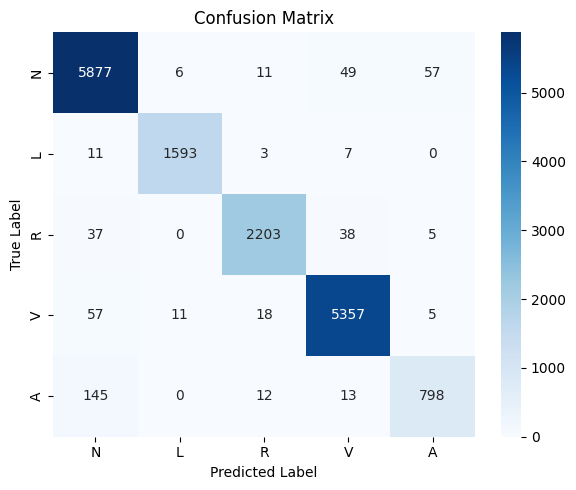


=== Sensitivity / Specificity ===
 N | SEN=0.9795 | SPEC=0.9758
 L | SEN=0.9870 | SPEC=0.9988
 R | SEN=0.9650 | SPEC=0.9969
 V | SEN=0.9833 | SPEC=0.9902
 A | SEN=0.8244 | SPEC=0.9956

Macro SEN=0.9478, Macro SPEC=0.9915


In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.backends.quantized.engine = "fbgemm"

model = ECGNet_QAT(num_classes=len(CLASSES)).to(device)


qat_qconfig = tq.get_default_qat_qconfig("fbgemm")
model.qconfig = qat_qconfig
model.transformer.qconfig = None
tq.prepare_qat(model, inplace=True)


criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6
)

history = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    device,
    epochs=100,
    save_path="/kaggle/working/ecgnet_qat_checkpoint.pt"
)

model.load_state_dict(torch.load("/kaggle/working/ecgnet_qat_checkpoint.pt"))

evaluate_and_report(
    model,
    test_loader,
    criterion,
    device,
    CLASSES
)

In [28]:
def plot_training_history(history):
    """
    Plot training and validation metrics over epochs.

    Expected keys in history dict:
        - train_loss, val_loss
        - train_acc,  val_acc
        - train_f1,   val_f1
    """

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # -------- Loss --------
    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # -------- Accuracy --------
    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    # -------- Macro F1 --------
    axes[2].plot(epochs, history["train_f1"], label="Train")
    axes[2].plot(epochs, history["val_f1"], label="Validation")
    axes[2].set_title("Macro F1-score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1-score")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

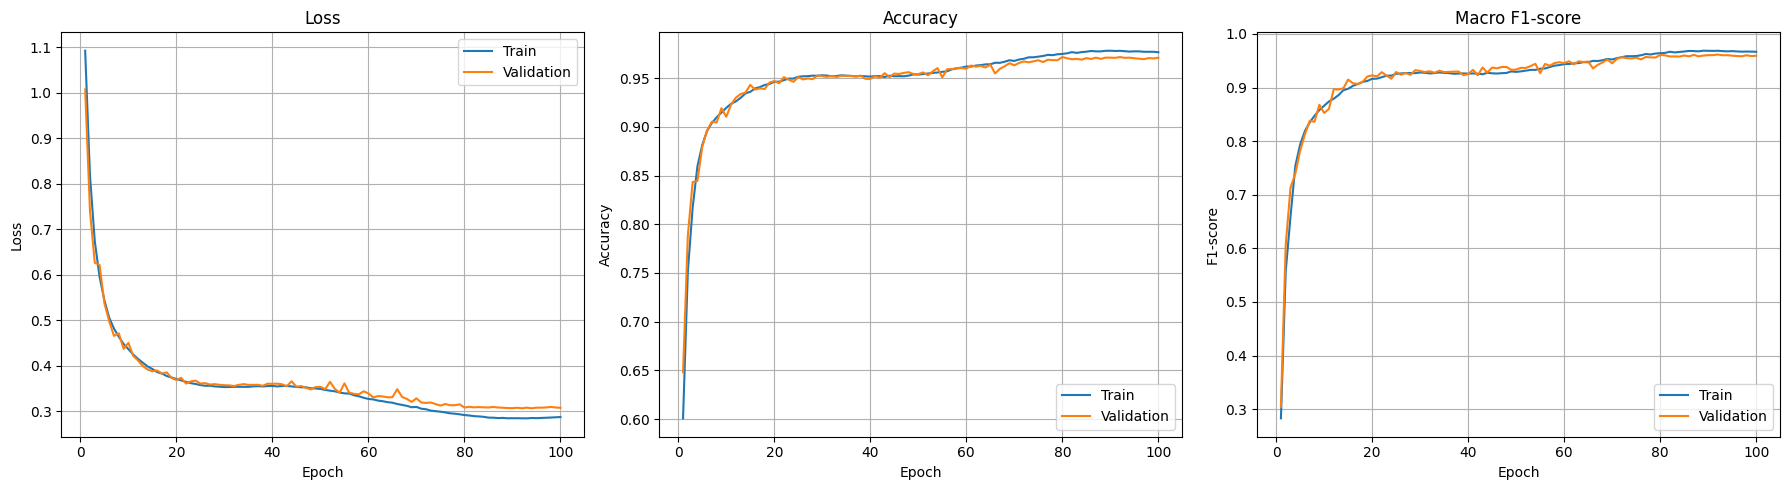

In [29]:
plot_training_history(history)

# Quantized

In [30]:
# =========================================
# 1. Create model
# =========================================
model = ECGNet_QAT(num_classes=len(CLASSES))

# =========================================
# 2. Quantization backend
# =========================================
torch.backends.quantized.engine = "fbgemm"

# =========================================
# 3. Set QAT config
# =========================================
model.qconfig = tq.get_default_qat_qconfig("fbgemm")

# IMPORTANT: exclude transformer
model.transformer.qconfig = None

# =========================================
# 4. Prepare QAT
# =========================================
tq.prepare_qat(model, inplace=True)

# =========================================
# 5. NOW load QAT checkpoint
# =========================================
ckpt_path = "/kaggle/working/ecgnet_qat_checkpoint.pt"
state_dict = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(state_dict)

# =========================================
# 6. Freeze
# =========================================
model.eval()
model.apply(tq.disable_observer)
model.apply(tq.disable_fake_quant)

# =========================================
# 7. Convert to INT8 inference model
# =========================================
model_int8 = tq.convert(model)

# =========================================
# 8. Save frozen INT8 model
# =========================================
torch.save(
    model_int8,
    "/kaggle/working/ecg1dnet_int8_checkpoint.pt"
)

print("QAT model successfully frozen and converted to INT8.")

QAT model successfully frozen and converted to INT8.


In [31]:
print(model_int8)

ECGNet_QAT(
  (quant): Quantize(scale=tensor([0.0726]), zero_point=tensor([58]), dtype=torch.quint8)
  (dequant): DeQuantize()
  (stem): Sequential(
    (0): QuantizedConv1d(1, 32, kernel_size=(5,), stride=(2,), scale=0.1409393697977066, zero_point=72, padding=(2,))
    (1): ReLU()
  )
  (res1): ResBlock(
    (block): Sequential(
      (0): QuantizedConv1d(32, 32, kernel_size=(3,), stride=(1,), scale=0.15492556989192963, zero_point=80, padding=(1,))
      (1): ReLU(inplace=True)
      (2): QuantizedConv1d(32, 32, kernel_size=(3,), stride=(1,), scale=0.13445231318473816, zero_point=70, padding=(1,))
    )
    (relu): ReLU(inplace=True)
    (skip_add): QFunctional(
      scale=0.1646769642829895, zero_point=56
      (activation_post_process): Identity()
    )
  )
  (down1): Sequential(
    (0): QuantizedConv1d(32, 64, kernel_size=(3,), stride=(2,), scale=0.2084815949201584, zero_point=86, padding=(1,))
    (1): ReLU()
  )
  (res2): ResBlock(
    (block): Sequential(
      (0): QuantizedC

In [32]:
x = torch.randn(1, 1, 320)

with torch.no_grad():
    y_qat = model(x)
    y_int8 = model_int8(x)

diff = torch.mean(torch.abs(y_qat - y_int8))
print("Mean abs diff:", diff.item())

Mean abs diff: 0.10845589637756348



=== INT8 TEST METRICS ===
Loss : 0.3422
ACC  : 0.9524
F1   : 0.9280

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           N     0.9596    0.9298    0.9445      6000
           L     0.9901    0.9876    0.9888      1614
           R     0.9791    0.9654    0.9722      2283
           V     0.9816    0.9813    0.9815      5448
           A     0.6820    0.8399    0.7528       968

    accuracy                         0.9524     16313
   macro avg     0.9185    0.9408    0.9280     16313
weighted avg     0.9562    0.9524    0.9537     16313



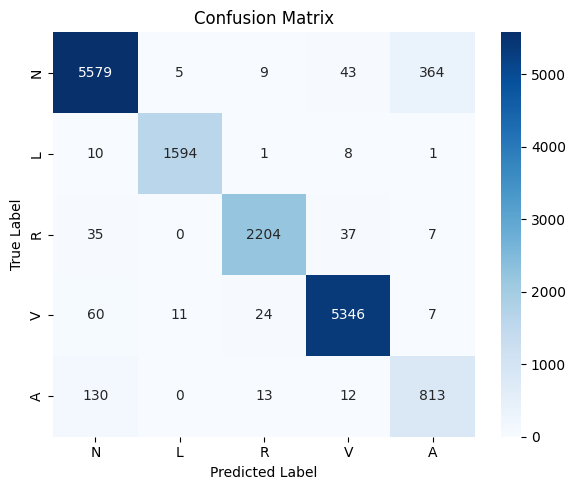


=== Sensitivity / Specificity ===
 N | SEN=0.9298 | SPEC=0.9772
 L | SEN=0.9876 | SPEC=0.9989
 R | SEN=0.9654 | SPEC=0.9967
 V | SEN=0.9813 | SPEC=0.9908
 A | SEN=0.8399 | SPEC=0.9753

Macro SEN=0.9408, Macro SPEC=0.9878


In [33]:
# INT8 inference: KHÔNG toggle eval/train nữa
with torch.inference_mode():
    loss, acc, f1, gts, preds = eval_model_full_int8(
        model_int8,
        test_loader,
        criterion,
        device="cpu"
    )

print("\n=== INT8 TEST METRICS ===")
print(f"Loss : {loss:.4f}")
print(f"ACC  : {acc:.4f}")
print(f"F1   : {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    gts, preds,
    target_names=CLASSES,
    digits=4
))

cm = plot_confusion_matrix(gts, preds, CLASSES)
sens, spec = sensitivity_specificity(cm)

print("\n=== Sensitivity / Specificity ===")
for i, c in enumerate(CLASSES):
    print(f"{c:>2} | SEN={sens[i]:.4f} | SPEC={spec[i]:.4f}")

print(
    f"\nMacro SEN={sens.mean():.4f}, "
    f"Macro SPEC={spec.mean():.4f}"
)
